# Классификация пород кошек и собак по лицу

Используем упрощенный датасет [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) с вырезанными лицами домашних животных. Для начала загружаем датасет:

In [3]:
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2026-04-21 21:28:29--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   755KB/s    in 37s     

2026-04-21 21:29:07 (639 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



Для визуализации списка изображений можно использовать такую функцию:

In [6]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()
!ls

petfaces  README.md  sample_data


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, top_k_accuracy_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_path = "./petfaces"
breeds = sorted(os.listdir(data_path))

print(len(breeds))

cat_breeds = set()
dog_breeds = set()
breed = set()
# Определяем породы кошек (нужно уточнить по факту)
for ls in breeds:
    l = ls.split('_')
    if(l[0] == "cat"):
        cat_breeds.add(l[1])
    if(l[0] == "dog"):
        dog_breeds.add(l[1])
    breed.add(l[1])


breed_to_id = {breed: i for i, breed in enumerate(breeds)}
breed_to_animal = {br: 0 if br.split("_")[1] in cat_breeds else 1 for br in breeds}

image_paths, breed_labels, animal_labels = [], [], []
for breed in breeds:
    breed_dir = os.path.join(data_path, breed)
    if not os.path.isdir(breed_dir):
        continue
    for img in os.listdir(breed_dir):
        if img.endswith(('.jpg', '.png')):
            image_paths.append(os.path.join(breed_dir, img))
            breed_labels.append(breed_to_id[breed])
            animal_labels.append(breed_to_animal[breed])

35


# 2. ПРЕДОБРАБОТКА


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class PetDataset(Dataset):
    def __init__(self, paths, breed_labels, animal_labels, transform):
        self.paths = paths
        self.breed_labels = breed_labels
        self.animal_labels = animal_labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.breed_labels[idx], self.animal_labels[idx]

# Stratified split
train_idx, test_idx = train_test_split(range(len(image_paths)), test_size=0.2,
                                        stratify=breed_labels, random_state=42)

train_dataset = PetDataset([image_paths[i] for i in train_idx],
                           [breed_labels[i] for i in train_idx],
                           [animal_labels[i] for i in train_idx], train_transform)
test_dataset = PetDataset([image_paths[i] for i in test_idx],
                          [breed_labels[i] for i in test_idx],
                          [animal_labels[i] for i in test_idx], test_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    

#  3. АРХИТЕКТУРА СЕТИ 

In [9]:
class PetCNN(nn.Module):
    def __init__(self, num_breeds=35):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.breed_classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.5), nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_breeds)
        )
        self.animal_classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.5), nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, 2)
        )
    def forward(self, x):
        x = self.features(x)
        return self.breed_classifier(x), self.animal_classifier(x)

print("architecture starts")
model = PetCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("architecture done")


architecture starts
architecture done



#  4. ОБУЧЕНИЕ 


In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss_breed, total_loss_animal, correct_breed, correct_animal, total = 0, 0, 0, 0, 0
    for images, breed_labels, animal_labels in loader:
        images, breed_labels, animal_labels = images.to(device), breed_labels.to(device), animal_labels.to(device)
        optimizer.zero_grad()
        breed_out, animal_out = model(images)
        loss = criterion(breed_out, breed_labels) + criterion(animal_out, animal_labels)
        loss.backward()
        optimizer.step()
        total_loss_breed += criterion(breed_out, breed_labels).item()
        total_loss_animal += criterion(animal_out, animal_labels).item()
        correct_breed += (breed_out.argmax(1) == breed_labels).sum().item()
        correct_animal += (animal_out.argmax(1) == animal_labels).sum().item()
        total += images.size(0)
    return (total_loss_breed/len(loader), total_loss_animal/len(loader),
            correct_breed/total, correct_animal/total)

def evaluate(model, loader):
    model.eval()
    correct_breed, correct_animal, total = 0, 0, 0
    all_breed_preds, all_breed_true = [], []
    all_animal_preds, all_animal_true = [], []
    with torch.no_grad():
        for images, breed_labels, animal_labels in loader:
            images = images.to(device)
            breed_out, animal_out = model(images)
            correct_breed += (breed_out.argmax(1).cpu() == breed_labels).sum().item()
            correct_animal += (animal_out.argmax(1).cpu() == animal_labels).sum().item()
            total += images.size(0)
            all_breed_preds.extend(breed_out.argmax(1).cpu().numpy())
            all_breed_true.extend(breed_labels.numpy())
            all_animal_preds.extend(animal_out.argmax(1).cpu().numpy())
            all_animal_true.extend(animal_labels.numpy())
    return (correct_breed/total, correct_animal/total,
            all_breed_preds, all_breed_true, all_animal_preds, all_animal_true)

print("Обучение...")
for epoch in range(15):  #15 поставить потом
    train_loss_b, train_loss_a, train_acc_b, train_acc_a = train_epoch(model, train_loader)
    print(f"Epoch {epoch+1}: Breed Acc={train_acc_b*100:.2f}%, Animal Acc={train_acc_a*100:.2f}%")


Обучение...
Epoch 1: Breed Acc=11.84%, Animal Acc=67.99%
Epoch 2: Breed Acc=15.34%, Animal Acc=71.57%
Epoch 3: Breed Acc=17.64%, Animal Acc=73.91%
Epoch 4: Breed Acc=19.00%, Animal Acc=76.44%
Epoch 5: Breed Acc=22.12%, Animal Acc=80.72%
Epoch 6: Breed Acc=25.16%, Animal Acc=82.98%
Epoch 7: Breed Acc=27.34%, Animal Acc=85.79%
Epoch 8: Breed Acc=29.32%, Animal Acc=88.32%
Epoch 9: Breed Acc=30.33%, Animal Acc=88.47%
Epoch 10: Breed Acc=32.52%, Animal Acc=88.94%
Epoch 11: Breed Acc=33.49%, Animal Acc=91.12%
Epoch 12: Breed Acc=35.32%, Animal Acc=91.51%
Epoch 13: Breed Acc=37.73%, Animal Acc=92.06%
Epoch 14: Breed Acc=38.82%, Animal Acc=93.42%
Epoch 15: Breed Acc=36.60%, Animal Acc=92.56%

=== РЕЗУЛЬТАТЫ ===
Бинарная классификация (кошка/собака): 94.56%
Мультиклассовая (36 пород): 40.90%


ValueError: Number of given labels (36) not equal to the number of classes in 'y_score' (35).

#  5. РЕЗУЛЬТАТЫ 

In [14]:


test_acc_breed, test_acc_animal, breed_preds, breed_true, animal_preds, animal_true = evaluate(model, test_loader)

print(f"\n=== РЕЗУЛЬТАТЫ ===")
print(f"Бинарная классификация (кошка/собака): {test_acc_animal*100:.2f}%")
print(f"Мультиклассовая (35 пород): {test_acc_breed*100:.2f}%")



=== РЕЗУЛЬТАТЫ ===
Бинарная классификация (кошка/собака): 94.56%
Мультиклассовая (35 пород): 40.90%


Top-3 Accuracy: 72.63%


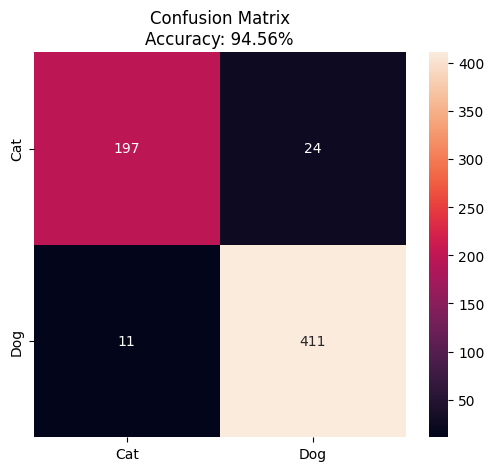

In [13]:

# Top-3 accuracy
from sklearn.preprocessing import label_binarize
model.eval()
all_probs = []
with torch.no_grad():
    for images, _, _ in test_loader:
        breed_out, _ = model(images.to(device))
        all_probs.append(torch.softmax(breed_out, dim=1).cpu().numpy())
all_probs = np.vstack(all_probs)
top3 = top_k_accuracy_score(breed_true, all_probs, k=3, labels=range(35))
print(f"Top-3 Accuracy: {top3*100:.2f}%")

# Confusion Matrix для бинарной классификации
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(animal_true, animal_preds), annot=True, fmt='d', 
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title(f'Confusion Matrix\nAccuracy: {test_acc_animal*100:.2f}%')
plt.savefig('confusion_matrix.png')
plt.show()